In [1]:
import cv2
import numpy as np

In [2]:
yolo_weights = "C:\PyProjects\Learn_Python_codes\Deep_learning\YOLOv3\pretrained_yolo\yolov3.weights"
yolo_configs = "C:\PyProjects\Learn_Python_codes\Deep_learning\YOLOv3\pretrained_yolo\yolo_data\yolov3.cfg"

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_1500/726849547.py:1: SyntaxWarning: invalid escape sequence '\P'
  yolo_weights = "C:\PyProjects\Learn_Python_codes\Deep_learning\YOLOv3\pretrained_yolo\yolov3.weights"
/tmp/ipykernel_1500/726849547.py:2: SyntaxWarning: invalid escape sequence '\P'
  yolo_configs = "C:\PyProjects\Learn_Python_codes\Deep_learning\YOLOv3\pretrained_yolo\yolo_data\yolov3.cfg"


In [5]:
!git clone https://github.com/fazelelham32/Learn_PythonCodes.git

Cloning into 'Learn_PythonCodes'...
remote: Enumerating objects: 421, done.
remote: Total 421 (delta 0), reused 0 (delta 0), pack-reused 421 (from 1)
Receiving objects: 100% (421/421), 313.61 MiB | 29.99 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [9]:
import os

print(os.path.exists(cfg_path))
print(os.path.exists(weights_path))

True
False


In [10]:
!wget -O yolov3.weights https://pjreddie.com/media/files/yolov3.weights

--2026-08-04 19:43:41--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3036::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-08-04 19:43:41--  https://data.pjreddie.com/files/yolov3.weights
Resolving data.pjreddie.com (data.pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3036::6815:589c, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  53.0MB/s    in 5.2s    

2026-08-04 19:43:46 (45.8 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]



In [11]:
cfg_path = "/content/Learn_PythonCodes/Learn_Python_codes/DL/YOLO/YOLOv3/pretrained_yolo/yolo_data/yolov3.cfg"
weights_path = "/content/yolov3.weights"

import cv2
net = cv2.dnn.readNetFromDarknet(cfg_path, weights_path)

In [14]:
import urllib.request

url = "https://raw.githubusercontent.com/fazelelham32/Learn_PythonCodes/main/Learn_Python_codes/DL/YOLO/YOLOv3/pretrained_yolo/yolo_data/coco.names"

with urllib.request.urlopen(url) as f:
    classes = [line.decode('utf-8').strip() for line in f.readlines()]

In [17]:
import cv2
import urllib.request
import numpy as np

url = "https://raw.githubusercontent.com/fazelelham32/Learn_PythonCodes/main/Learn_Python_codes/Image_processing/Images/04_tehran.png"

resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

img = cv2.resize(img, None, fx=0.4, fy=0.4)
height, width, channels = img.shape

In [18]:
print(img is None)

False


In [19]:
blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)


In [21]:
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

net.setInput(blob)
outs = net.forward(output_layers)

In [22]:
colors = np.random.uniform(0, 255, size=(len(classes), 3))

[31 35  4 40  2 24  7 20 47 45 10 44 25 19 32 48 50 12 13 51]


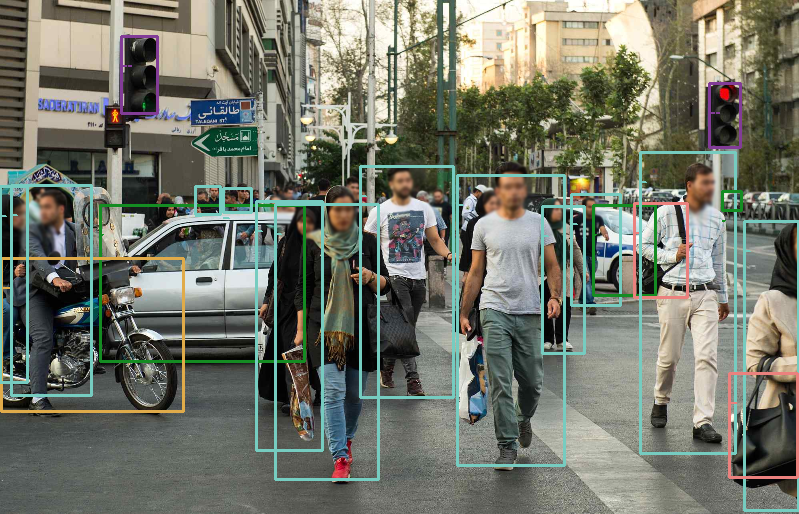

In [24]:

from google.colab.patches import cv2_imshow

# Showing informations on the screen
class_ids = []
confidences = []
boxes = []
for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            # Object detected
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)

            # Rectangle coordinates
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)

            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
print(indexes)
font = cv2.FONT_HERSHEY_PLAIN
for i in range(len(boxes)):
    if i in indexes:
        x, y, w, h = boxes[i]
        label = str(classes[class_ids[i]])
        color = colors[class_ids[i]]
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
        cv2.putText(img, label, (x, y + 30), font, 0.1, color, 1)


cv2_imshow(img)

In [25]:
cap = cv2.VideoCapture("C:\PyProjects\Learn_Python_codes\Image_processing\Videos\driving_camera.mp4")
while(cap.isOpened()):
  # Capture frame-by-frame
  ret, frame = cap.read()
  if ret == True:
    img = cv2.resize(frame, None, fx=0.8, fy=0.8)
    #cv2.imshow('Frame',img)
    height, width, channels = img.shape
    blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)
    class_ids = []
    confidences = []
    boxes = []
    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5:
                # Object detected
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)

                # Rectangle coordinates
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
    print(indexes)
    font = cv2.FONT_HERSHEY_PLAIN
    for i in range(len(boxes)):
        if i in indexes:
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])
            color = colors[class_ids[i]]
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            cv2.putText(img, label, (x, y + 30), font, 2, color, 2)


    cv2.imshow('Frame',img)
    if cv2.waitKey(25) & 0xFF == ord('q'):
      break
cap.release()
cv2.destroyAllWindows()




<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_1500/3250613807.py:1: SyntaxWarning: invalid escape sequence '\P'
  cap = cv2.VideoCapture("C:\PyProjects\Learn_Python_codes\Image_processing\Videos\driving_camera.mp4")
